In [24]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd 
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

uri= 'https://gist.githubusercontent.com/guilhermesilveira/1b7d5475863c15f484ac495bd70975cf/raw/16aff7a0aee67e7c100a2a48b676a2d2d142f646/projects.csv'
dados = pd.read_csv(uri)
dados.head()


,unfinished,expected_hours,price
0,1,26,192
1,1,88,9015
2,1,89,2577
3,1,42,275
4,1,39,170


In [26]:
# Função para instanciar e treinar o modelo com os dados de treino
def treino(vars_x, vars_y):
    from sklearn.svm import LinearSVC

    md = LinearSVC()
    md.fit(vars_x, vars_y)

    return md

#Função para stratify e retorno dde acurácia
def return_acuracia(feature_x, feature_y):
    #import
    from collections import namedtuple
    from sklearn.metrics import accuracy_score
    from sklearn.model_selection import train_test_split

    # Outra maneira de separar os dados de treino e teste, no qual a separação de elementos menos aleatória com stratify e SEED.    
    treino_x, teste_x, treino_y, teste_y = train_test_split(feature_x, feature_y, random_state = 20, test_size = 0.25, stratify = y)
    
    # Modelo instanciado e treinado com as variáveis teste x e y, sendo assim, o algotirmo consegue entender como o conjunto de features de x se realciona com y.
    modelo_treinado = treino(treino_x, treino_y)

    # A partir do modelo treinado é possível predizer quais serão os valores de y.
    predicao = modelo_treinado.predict(teste_x)

    print(f"Treino feito com {len(treino_x)} elementos | Teste feito com {len(teste_x)} elementos ")

    # Medição da acurácia do modelo comparando os valores verdadeiros com os valores da predicao do modelo.
    acuracia = (accuracy_score(teste_y, predicao) * 100)
    

    msg_acuracia =  "A acurácia foi %.2f%%" % acuracia

    dt_return = namedtuple('func_data', ['modelo_treinado','treino_x', 'teste_x', 'treino_y', 'teste_y', 'msg_acuracia']) 

    
    return dt_return(
        treino_x=treino_x,
        treino_y=treino_y,
        teste_x=teste_x,
        teste_y=teste_y,
        msg_acuracia=msg_acuracia,
        modelo_treinado=modelo_treinado

    )




In [27]:
a_renomear = {
    'unfinished' : 'nao_finalizado',
    'expected_hours' : 'horas_experadas',
    'price':'preco'
}

dados = dados.rename(columns=a_renomear)

In [28]:
a_renomear = {
    'unfinished':'nao_finalizado',
    'expected_hours':'horas_esxeradas',
    'price':'preco'
}

dados = dados.rename(columns=a_renomear)

In [29]:
trocas = {
    0 : 1,
    1: 0
}

dados['finalizado'] = dados.nao_finalizado.map(trocas)

In [30]:
dados.head()

,nao_finalizado,horas_experadas,preco,finalizado
0,1,26,192,0
1,1,88,9015,0
2,1,89,2577,0
3,1,42,275,0
4,1,39,170,0


Abaixo temos um gráfico de 3 dimensões: eixo x, eixo y e cor

<Axes: xlabel='horas_experadas', ylabel='preco'>

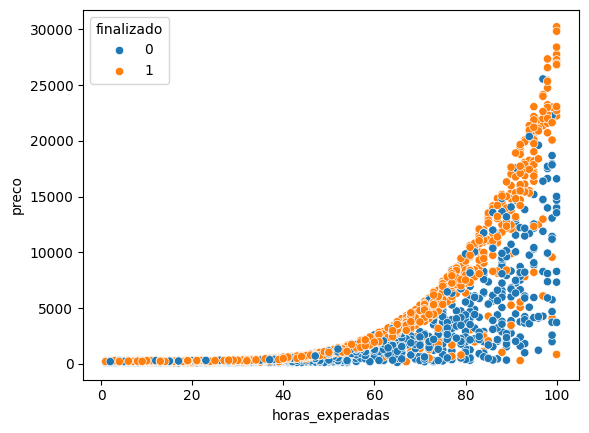

In [31]:
sns.scatterplot(x='horas_experadas', y='preco', hue='finalizado',data = dados)

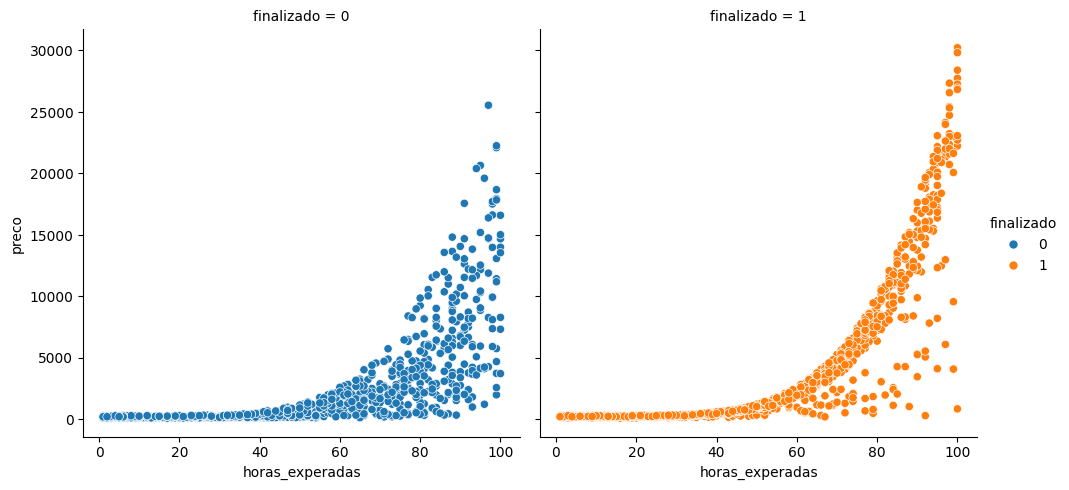

In [32]:
sns.relplot(x='horas_experadas', y='preco', col='finalizado', hue='finalizado',data = dados)

In [33]:
x = dados[['horas_experadas', 'preco']]
y = dados['finalizado']

In [34]:
resultado = return_acuracia(x,y)

print(resultado.msg_acuracia)

Treino feito com 1617 elementos | Teste feito com 540 elementos 
A acurácia foi 54.44%


In [35]:
import numpy as np

base_line = np.ones(540)

In [36]:
print('A acuracia de base line foi %.2f%%' % (accuracy_score(resultado.teste_y, base_line) * 100))

A acuracia de base line foi 52.59%


<Axes: xlabel='horas_experadas', ylabel='preco'>

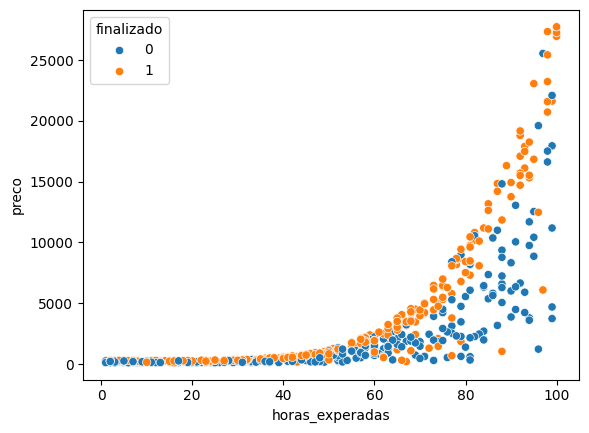

In [37]:
sns.scatterplot(x='horas_experadas', y='preco', hue=resultado.teste_y, data=resultado.teste_x)

In [38]:
min_x = resultado.teste_x.horas_experadas.min()
max_x = resultado.teste_x.horas_experadas.max()

min_y = resultado.teste_x.preco.min()
max_y = resultado.teste_x.preco.max()


print(f'min x horas => {min_x}, max x horas=> {max_x}, min y preco => {min_y}, max y preco=> {max_y}')

min x horas => 1, max x horas=> 100, min y preco => 101, max y preco=> 27738


In [39]:
pixels = 100
eixo_x = np.arange(min_x, max_x, (max_x - min_x) / pixels)
eixo_y = np.arange(min_y, max_y, (max_y - min_y) / pixels)




In [40]:
xx, yy = np.meshgrid(eixo_x, eixo_y)

pontos = np.c_[xx.ravel(), yy.ravel()]
pontos

array([[1.000000e+00, 1.010000e+02],
       [1.990000e+00, 1.010000e+02],
       [2.980000e+00, 1.010000e+02],
       ...,
       [9.703000e+01, 2.746163e+04],
       [9.802000e+01, 2.746163e+04],
       [9.901000e+01, 2.746163e+04]])

In [41]:
# contante para limitar a aleatoriedade da separação de dados da biblioteca do Sk Learn
SEED = 20

# Atribuindo uma referência ao conjunto de y para realizar uma estratifição que possa gerar os dados de treino e teste de maneira proporcional com base em y
strfy = y

# Outra maneira de separar os dados de treino e teste, no qual a separação de elementos é aleatória.
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, test_size = 0.25, stratify = y)

# Função para instanciar e treinar o modelo com os dados de treino

from sklearn.svm import LinearSVC

md_aux = LinearSVC()
md_aux.fit(treino_x, treino_y)



# Modelo instanciado e treinado com as variáveis teste x e y, sendo assim, o algotirmo consegue entender como o conjunto de features de x se realciona com y.


# A partir do modelo treinado é possível predizer quais serão os valores de y.
predicao = md_aux.predict(teste_x)

# Medição da acurácia do modelo comparando os valores verdadeiros com os valores da predicao do modelo.
acuracia = accuracy_score(teste_y, predicao) * 100

msg_acuracia =  "A acurácia foi %.2f%%" % acuracia

msg_acuracia

'A acurácia foi 54.44%'

In [42]:
z = resultado.modelo_treinado.predict(pontos)
z = z.reshape(xx.shape)
z

C:\Users\luizf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


array([[1, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int64)

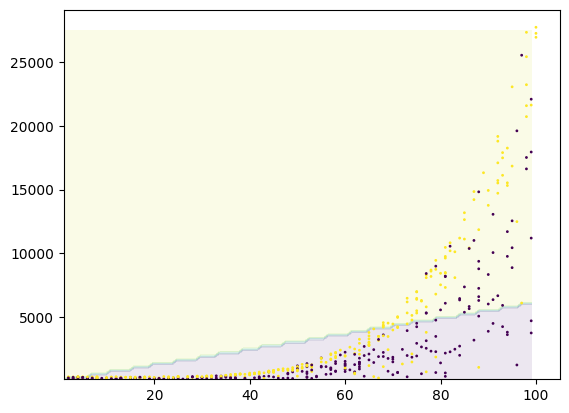

In [43]:
import matplotlib.pyplot as plt

plt.contourf(xx, yy, z, alpha=0.1)
plt.scatter(resultado.teste_x.horas_experadas, resultado.teste_x.preco, c=resultado.teste_y, s=1)